## 作业1
#### 分别计算return_1m、turn_1m、std_1m、std_FF3factor_1m因子并测试效果

- 首先导入必要的python库

In [50]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from scipy.stats import zscore
import matplotlib.pyplot as plt        
import gc
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

- DataLoader: 数据加载类，对于每只股票读取所需要的数据并根据日期进行切片。

In [ ]:
class DataLoader:
    def __init__(self, data_path):
        self.path = data_path
        
        day_df = pd.read_csv(data_path + 'day.csv')
        dates = pd.to_datetime(day_df['date'], errors='coerce')  # 日期
        
        stock_code_df = pd.read_csv(data_path + 'stock_code_info.csv')
        codes = stock_code_df['stock_code'].values  # 股票代码
        
        # 读取日频矩阵数据：原始数据中行是股票，列是日期
        def load_matrix(file_name):
            df = pd.read_csv(data_path + file_name, index_col=0)  
            df = df.T  
            df.index = dates
            df.columns = codes
            df = df.apply(pd.to_numeric, errors='coerce')
            return df
        
        self.close_adj = load_matrix('close_adj_day.csv')  # 后复权收盘价
        self.close = load_matrix('close_day.csv')  # 原始收盘价
        self.amt = load_matrix('amt_day.csv')  # 成交额
        self.turnover = load_matrix('turn_day.csv')  # 换手率
        self.float_share = load_matrix('float_a_shares_day.csv')  # A股流通股本
        self.industry = load_matrix('cs_indus_code_day.csv')  # 中信一级行业代码
        self.share_total = load_matrix('share_totala_day.csv')  # 日频A股总股本
        self.pb = load_matrix('pb_lf_day.csv')  # 市净率
        
      
        csiall_df = pd.read_csv(data_path + 'csiall_day.csv', index_col=0)  
        csiall_row = csiall_df.iloc[0]  
        csiall_values = pd.to_numeric(csiall_row, errors='coerce').values
        self.csiall = pd.Series(csiall_values, index=dates, name='csiall')  # 中证全指收盘价
        
        ipo_df = pd.read_csv(data_path + 'IPO_date_info.csv', index_col=0)
        self.ipo_date = pd.to_datetime(ipo_df['IPO_date'], errors='coerce')  # 上市日期
        
        delist_df = pd.read_csv(data_path + 'delist_date_info.csv', index_col=0)
        self.delist_date = pd.to_datetime(delist_df['delist_date'], errors='coerce')  # 退市日期
        
        self.trading_days = pd.DatetimeIndex(dates)  
        self.pct_chg = self.close_adj.pct_change(fill_method=None)  # 计算日收益率
        
        print(f"交易日数量: {len(self.trading_days)} 天")
        print(f"股票数量: {len(codes)} 只")
        print(f"日期范围: {dates.min()} ~ {dates.max()}")
        
    def get_slice(self, end_date, window=30):
        """
        获取截止到 end_date 过去 window 天的数据切片
        """
        loc = self.trading_days.get_loc(end_date)
        start_loc = max(0, loc - window + 1)
        slice_dates = self.trading_days[start_loc : loc+1]  # 日期切片
        
        return {
            'pct_chg': self.pct_chg.loc[slice_dates],
            'close_adj': self.close_adj.loc[slice_dates],
            'turnover': self.turnover.loc[slice_dates],
            'close': self.close.loc[slice_dates],
        }

- ff3_help：计算SMB因子日收益率和HML因子日收益率的辅助函数

In [23]:
def ff3_help(returns, factor_values, quantile=0.3):
    """
    参数:
        returns: (N,) 个股收益率数组
        factor_values: (N,) 排序因子数组 (如市值、BP)
        quantile: 分位数 (默认0.3，即前30%和后30%)
    返回:
        (mean_bottom, mean_top): (数值最小组均值, 数值最大组均值)
    """
    
    sort_idx = np.argsort(factor_values)
    
    n = len(sort_idx)
    cut = int(n * quantile)
    if cut == 0: return np.nan, np.nan

    idx_bottom = sort_idx[:cut]      # 数值最小的 30%
    idx_top = sort_idx[-cut:]        # 数值最大的 30%
    
    # 计算组内平均收益
    mean_bottom = np.mean(returns[idx_bottom])
    mean_top = np.mean(returns[idx_top])
    
    return mean_bottom, mean_top

- FF3factor：用于构建中证全指日收益率、SMB因子日收益率、HML因子日收益率序列

In [24]:
def FF3factor(loader):
    """
    计算中证全指日收益率、SMB因子日收益率、HML因子日收益率
    """
    
    # 中证全指日收益率
    csiall_ret = loader.csiall.pct_change(fill_method=None)
    csiall_ret.name = 'csiall'
    
    total_mkt_cap = loader.close * loader.share_total # 总市值
    inv_pb = 1.0 / loader.pb # 1/PB(市净率)
    
    smb_list = []
    hml_list = []
    dates = loader.pct_chg.index
    returns_matrix = loader.pct_chg
    
    # 转为numpy
    val_ret = returns_matrix.values
    val_cap = total_mkt_cap.values
    val_bp = inv_pb.values # BP = 1/PB
    
    for i in range(len(dates)):

        # 当日截面数据
        r = val_ret[i, :] 
        cap = val_cap[i, :]
        bp = val_bp[i, :]
        
        # 有效数据掩码 (必须收益、市值、BP都有值)
        valid = ~np.isnan(r) & ~np.isnan(cap) & ~np.isnan(bp)
        
        if np.sum(valid) < 10: # 样本太少
            smb_list.append(np.nan)
            hml_list.append(np.nan)
            continue
            
        r_valid = r[valid]
        cap_valid = cap[valid]
        bp_valid = bp[valid]
        
        # 计算 SMB(后30% - 前30%)
        r_small, r_big = ff3_help(r_valid, cap_valid, quantile=0.3)
        smb = r_small - r_big
        
        # 计算 HML(前30% - 后30%)
        r_L, r_H = ff3_help(r_valid, bp_valid, quantile=0.3)
        hml = r_H - r_L 
        
        smb_list.append(smb)
        hml_list.append(hml)
        
    ff3 = pd.DataFrame({
        'csiall': csiall_ret,
        'SMB': smb_list,
        'HML': hml_list
    }, index=dates)

    ff3 = ff3.dropna() 
    print(f"FF3 因子预计算完成，有效交易日: {len(ff3)}")
    return ff3

- regression_ff3: 计算个股最近21个交易日内，日收益率序列对中证全指日收益率、SMB因子日收益率、HML因子日收益率序列进行多元线性回归的残差

In [25]:
def regression_ff3(y_slice, x_df):
    """
    y_slice: (T, N) 个股日收益率矩阵 (21天)
    x_df: (T, 3) 因子收益率矩阵 (csiall, SMB, HML)
    """
    
    T = len(x_df)
    if T < 20: 
        print("样本量不足，无法进行回归")
        return pd.Series(np.nan, index=y_slice.columns)
    
    X = x_df.values 
    if np.isnan(X).any():
        print("因子数据中存在缺失值，无法进行回归")
        return pd.Series(np.nan, index=cols)
    # 添加常数项
    X = np.hstack([np.ones((T, 1)), X]) # (21, 4)
    
    Y = y_slice.values # (21, N)
    valid_mask = ~np.isnan(Y).any(axis=0) # 只有当该股票在T天内没有任何缺失值，才进行回归
    if not np.any(valid_mask):
        print("所有股票均存在缺失值，无法进行回归")
        return pd.Series(np.nan, index=cols)
    Y_valid = Y[:, valid_mask]

    results = []
    cols = y_slice.columns
    
    try:
        # 计算 (X.T @ X)^(-1) @ X.T
        X_pinv = np.linalg.pinv(X) # (X.T @ X)^(-1) @ X.T
        Betas = X_pinv @ Y_valid # 回归系数(4, N)
        Y_hat = X @ Betas # 回归估计值(21, N)
        Resid = Y_valid - Y_hat # 残差
        resid_std = np.nanstd(Resid, axis=0, ddof=4) # 残差标准差
    except Exception as e:
        print(f"Error: {e}")
        return pd.Series(np.nan, index=cols)
    
    result = np.full(len(cols), np.nan)
    result[valid_mask] = resid_std
    
    return pd.Series(result, index=cols)

## 股票池筛选
- get_valid_mask: 在每个月末界面日剔除不满足要求的股票，生成符合要求的股票掩码

In [26]:
def get_valid_mask(date, codes, ipo_date_series, delist_date_series, amt_slice):
    """
    股票池筛选：生成当天的有效股票
    剔除上市不满252天、退市、停牌
    """
    
    valid_ipo = ipo_date_series <= (date - pd.Timedelta(days=252)) # 上市已满252天
    valid_delist = delist_date_series.isna() | (delist_date_series > date) # 未退市
    current_amt = amt_slice.loc[date]
    valid_trade = (current_amt > 0) & current_amt.notna() # 剔除停牌（当日成交额为0）

    mask = valid_ipo.reindex(codes, fill_value=False) & \
           valid_delist.reindex(codes, fill_value=False) & \
           valid_trade.reindex(codes, fill_value=False)
    
    print(f"掩码长度：{len(mask)}")
    print(f"日期{date}，有效股票数量：{mask.sum()} 只")
           
    return mask

## 因子预处理
- rm_outliers: 去极值，超出三倍标准差的值将被截断

In [27]:
def rm_outliers(series, n=3):
    """
    去极值：3倍标准差
    """
    if series.empty: return series
    mean = series.mean()
    std = series.std()
    up = mean + n * std # 上界
    down = mean - n * std # 下界
    return series.clip(lower=down, upper=up) # clip函数将超出区间的值截断

- standardize: 标准化为标准正态分布

In [28]:
def standardize(series):
    """
    标准化：Z-Score
    """
    if series.std() == 0: return series
    return (series - series.mean()) / series.std()

- neutralize: 行业市值中性化，以去极值后的因子值为因变量，以A股市值因子、中信一级行业哑变量为自变量，OLS多元线性回归，取残差

In [29]:
def neutralize(factor_series, mkt_cap_series, industry_series):
    """
    行业市值中性化
    factor_series: 原始因子值 (已去极值)
    mkt_cap_series: A股市值因子
    industry_series: 中信一级行业哑变量
    """
    
    # 处理A股市值因子
    ln_cap = np.log(mkt_cap_series.replace(0, np.nan))  # 避免 log(0) 产生 -inf
    ln_cap = ln_cap.replace([np.inf, -np.inf], np.nan)  # 替换 inf 为 nan
    ln_cap = rm_outliers(ln_cap)  # 去极值
    ln_cap = standardize(ln_cap)  # 标准化
    
    # 将中信一级行业代码转为哑变量
    dummies = pd.get_dummies(industry_series, prefix='ind').astype(float)  
    cols_to_drop = [c for c in dummies.columns if c.endswith('_30') or c.endswith('_30.0')]
    if cols_to_drop:
        dummies = dummies.drop(columns=cols_to_drop)
    
    valid_idx = factor_series.dropna().index.intersection(ln_cap.dropna().index).intersection(dummies.index)
    
    if len(valid_idx) == 0:
        return pd.Series(np.nan, index=factor_series.index)
    
    Y = factor_series.loc[valid_idx].values.astype(float)  
    X = pd.concat([ln_cap.loc[valid_idx], dummies.loc[valid_idx]], axis=1)
    X = sm.add_constant(X.values.astype(float))  
    
    model = sm.OLS(Y, X).fit()  # 回归
    resid = pd.Series(model.resid, index=valid_idx)  
    
    return resid.reindex(factor_series.index)

- process：整合因子预处理，包括去极值、行业市值中性化、标准化

In [30]:
def process(curr_float_cap,curr_ind,raw_factor):
            valid_factor = rm_outliers(raw_factor)
            factor_neu = neutralize(valid_factor, curr_float_cap, curr_ind)
            factor_final = standardize(factor_neu)
            return factor_final

## 计算原始因子
- raw_factors: 计算 return_1m, turn_1m 等原始因子值

In [34]:
def raw_factors(date, history_slice,ff3_daily_df):
    """
    计算原始因子值
    history_slice: 包含过去 N 天数据的字典
    """

    # return_1m: 个股最近21个交易日区间收益率
    # 使用后复权收盘价计算，当前价格不变，调整历史价格
    _close_adj = history_slice['close_adj']
    if len(_close_adj) < 22:
        print(f"数据不足21天，无法计算Return_1m和Turn_1m")
        return pd.Series(np.nan, index=_close_adj.columns), pd.Series(np.nan, index=_close_adj.columns)
    
    return_1m = _close_adj.iloc[-1] / _close_adj.iloc[0] - 1 # 计算个股最近21个交易日区间收益率
    
    # turn_1m: 个股最近21个交易日内，每日换手率的均值
    turns = history_slice['turnover']
    turns[turns < 0] = np.nan
    turn_1m = turns.iloc[-21:].mean() # 取均值

    pct_chg = history_slice['pct_chg'] # 日收益率

    # std_1m: 个股最近21个交易日内，每日收益率的标准差
    std_1m = pct_chg.std()

    # std_FF3factor_1m：个股最近21个交易日内
    # 日收益率序列对中证全指日收益率、SMB因子日收益率、HML因子日收益率序列进行多元线性回归的残差的标准差
    common_idx = pct_chg.index.intersection(ff3_daily_df.index)
    if len(common_idx) < 20:
        std_FF3 = pd.Series(np.nan, index=pct_chg.columns)
    else:
        sub_FF3 = ff3_daily_df.reindex(common_idx)
        pct_chg_sub = pct_chg.reindex(common_idx)
        std_FF3 = regression_ff3(pct_chg_sub, sub_FF3)
    
    return return_1m, turn_1m, std_1m, std_FF3

- run_pipeline(主函数)：进行股票池筛选、计算原始因子和因子预处理

In [32]:
def run_pipeline(data_loader):
    
    ff3 = FF3factor(data_loader)
    # 生成月末截面列表 (2010-12 到 2024-11)
    all_days = pd.Series(data_loader.trading_days, index=data_loader.trading_days)
    month_ends = all_days.resample('M').last()
    month_ends = month_ends['2010-12':'2024-11']
    
    factor_names = ['return_1m', 'turn_1m', 'std_1m', 'std_FF3_1m'] # 需要计算的四个因子
    storage = {name: {'raw': [], 'processed': []} for name in factor_names} # 每个因子需要存储原始和处理后的结果

    print(f"开始处理 {len(month_ends)} 个月度截面...")
    
    for date in month_ends:
        if date is pd.NaT:
            print("NaT\n")
        else:
            date_str = date.strftime('%Y-%m-%d')
            print(f"正在处理截面: {date_str} ...", end="")
        
        slice_data = data_loader.get_slice(date, window=22) # 获取过去21天的数据
        codes = data_loader.close.columns  
        
        # 股票池筛选
        mask = get_valid_mask(
            date, codes, 
            data_loader.ipo_date, 
            data_loader.delist_date, 
            data_loader.amt 
        )
        
        # 计算原始因子
        raw_return_1m, raw_turn_1m,raw_std_1m, raw_std_FF3_1m = raw_factors(date, slice_data,ff3)
        
        # 提取有效股票的掩码
        valid_codes = mask[mask].index
        
        if len(valid_codes) == 0:
            print(" 无有效股票")
            continue
        
        current_factors = {
            'return_1m': raw_return_1m,
            'turn_1m': raw_turn_1m,
            'std_1m': raw_std_1m,
            'std_FF3_1m': raw_std_FF3_1m
        }
        
        curr_float_cap = data_loader.float_share.loc[date, valid_codes] * data_loader.close.loc[date, valid_codes] # 流通市值
        curr_ind = data_loader.industry.loc[date, valid_codes] # 中信一级行业

        for name in factor_names:
            if name not in current_factors: continue 
            
            raw = current_factors[name].reindex(codes) 
            raw = raw.where(mask) 
            raw = raw.loc[valid_codes] # 筛选股票池
            raw.name = date
            storage[name]['raw'].append(raw) # 存储原始因子
        
            processed = process(curr_float_cap, curr_ind, raw) # 因子预处理
            processed = processed.reindex(codes)
            processed.name = date
            storage[name]['processed'].append(processed) # 存储处理后的因子
            
    output = {}
    for name in factor_names:

        if not storage[name]['raw']: continue
        
        # 合并原始因子
        df_raw = pd.DataFrame(storage[name]['raw'])
        df_raw.index.name = 'date'
        output[f'factor_{name}_raw'] = df_raw
        
        # 合并处理后的因子
        df_proc = pd.DataFrame(storage[name]['processed'])
        df_proc.index.name = 'date'
        output[f'factor_{name}_processed'] = df_proc

    return output

- 运行上面所写的函数，得到原始因子值和预处理后的因子值，共8个Dataframe(.csv文件)

In [44]:
loader = DataLoader('data/')
output = run_pipeline(loader)
for name, df in output.items():
    df.to_csv(f"{name}.csv")

数据加载完成。
交易日数量: 6521 天
股票数量: 5661 只
日期范围: 1998-01-05 00:00:00 ~ 2024-11-29 00:00:00
FF3 因子预计算完成，有效交易日: 4835
开始处理 168 个月度截面...
正在处理截面: 2010-12-31 ...掩码长度：5661
日期2010-12-31 00:00:00，有效股票数量：1720 只
正在处理截面: 2011-01-31 ...掩码长度：5661
日期2011-01-31 00:00:00，有效股票数量：1741 只
正在处理截面: 2011-02-28 ...掩码长度：5661
日期2011-02-28 00:00:00，有效股票数量：1753 只
正在处理截面: 2011-03-31 ...掩码长度：5661
日期2011-03-31 00:00:00，有效股票数量：1781 只
正在处理截面: 2011-04-29 ...掩码长度：5661
日期2011-04-29 00:00:00，有效股票数量：1786 只
正在处理截面: 2011-05-31 ...掩码长度：5661
日期2011-05-31 00:00:00，有效股票数量：1845 只
正在处理截面: 2011-06-30 ...掩码长度：5661
日期2011-06-30 00:00:00，有效股票数量：1838 只
正在处理截面: 2011-07-29 ...掩码长度：5661
日期2011-07-29 00:00:00，有效股票数量：1893 只
正在处理截面: 2011-08-31 ...掩码长度：5661
日期2011-08-31 00:00:00，有效股票数量：1933 只
正在处理截面: 2011-09-30 ...掩码长度：5661
日期2011-09-30 00:00:00，有效股票数量：1964 只
正在处理截面: 2011-10-31 ...掩码长度：5661
日期2011-10-31 00:00:00，有效股票数量：1999 只
正在处理截面: 2011-11-30 ...掩码长度：5661
日期2011-11-30 00:00:00，有效股票数量：2018 只
正在处理截面: 2011-12-30 ...掩码长度：5661
日期2011-12-30 00:00:00，有效股票数

## 因子检验
- next_month_returns: 计算下个自然月收益率

In [54]:
def next_month_returns(loader):
    """
    计算每只股票的下个自然月收益率
    """
    days = pd.Series(loader.trading_days, index=loader.trading_days)
    month_ends = days.resample('M').last().dropna()
    valid_dates = month_ends.values
    monthly_close = loader.close_adj.loc[valid_dates] # 月末后复权收盘价
    monthly_return = monthly_close.pct_change(fill_method=None)
    next_return = monthly_return.shift(-1)
    
    return next_return

- test_single: 对单个因子分别使用RankIC法和分层测试法进行因子检验

In [46]:
def test_single(factor_df, next_return):
    """
    对单个因子进行因子检验：RankIC法 和 分层测试法
    """
    common_dates = factor_df.index.intersection(next_return.index)
    # 剔除最后一行 (2024年11月底)
    last_date = common_dates[-1]
    if next_return.loc[last_date].isna().all():
        common_dates = common_dates[:-1]
        
    ic_list = []
    layer_returns = []
    
    for date in common_dates:
        
        f = factor_df.loc[date] # 当期因子值
        r = next_return.loc[date] # 下个月收益率
        
        # 排除 NaN (必须两者都有值)
        valid_mask = ~np.isnan(f) & ~np.isnan(r)
        
        if np.sum(valid_mask) < 10: # 样本太少跳过
            ic_list.append(np.nan)
            layer_returns.append([np.nan]*5)
            continue
            
        f_valid = f[valid_mask]
        r_valid = r[valid_mask]
        
        # RankIC法
        ic = spearmanr(f_valid, r_valid)[0] # spearman相关系数
        ic_list.append(ic)
        
        # 分层测试法
        try:
            # 最小的(0-20%) -> 第5层
            # 最大的(80-100%) -> 第1层
            labels = ['Layer5', 'Layer4', 'Layer3', 'Layer2', 'Layer1']
            groups = pd.qcut(f_valid, 5, labels=labels, duplicates='drop')
            
            # 计算每层的等权平均收益
            layer_ret = r_valid.groupby(groups).mean()
            
            # 确保 1-5 层都有值 (防止某层缺失)
            current_layer = []
            for layer_name in ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5']:
                current_layer.append(layer_ret.get(layer_name, np.nan))
                
            layer_returns.append(current_layer)
            
        except Exception as e:
            print(f"分层测试出错: {e}")
            layer_returns.append([np.nan]*5)

    df_ic = pd.DataFrame({'RankIC': ic_list}, index=common_dates)
    df_layers = pd.DataFrame(layer_returns, index=common_dates, columns=['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5'])
    result = pd.concat([df_ic, df_layers], axis=1)
    
    return result

- factor_tests: 因子检验主函数，调用上面的辅助函数对四个因子分别进行因子检验

In [47]:
def factor_tests(data_loader, factor_dfs):
 
    print("开始因子检验")
    
    next_ret = next_month_returns(data_loader)
    test_results = {}
    
    for name, df in factor_dfs.items():
        if 'processed' not in name: continue 
    
        base_name = name.replace('_processed', '')
        print(f"正在测试因子: {base_name} ...", end="")
        df_test = test_single(df, next_ret)
        test_results[f'{base_name}_test'] = df_test
        
        print(f" {base_name}因子检验完成. IC均值: {df_test['RankIC'].mean():.4f}")
        
    return test_results

- plot：绘图函数，累计RankIC绘图，5分层累计收益率绘图

In [ ]:
def plot(test_results):
    """
    绘制累积 RankIC 和 5分层累积收益图
    """
    try:
        import seaborn as sns
        sns.set_theme(style="whitegrid")
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
        plt.rcParams['axes.unicode_minus'] = False
    except:
        pass

    for name, df in test_results.items():
        if df.empty: continue
        
        factor_name = name.replace('_test', '')
        
        # 累积 RankIC
        fig1, ax1 = plt.subplots(figsize=(12, 6))
        df['RankIC'].cumsum().plot(ax=ax1, color='navy', linewidth=1.5)
        ax1.set_title(f'{factor_name} - 累积 RankIC', fontsize=12, fontweight='bold')
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累积 RankIC')
        ax1.axhline(0, color='black', linestyle='--', linewidth=0.8) 
        plt.tight_layout()
        plt.show()
        #fig1.savefig(f"{factor_name}_RankIC.png", dpi=300)
        
        # 5分层累积收益率
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        layers = df[['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5']]
        layers_cum = layers.cumsum()
        # Layer1 (最大) 用红色，Layer5 (最小) 用绿色/蓝色，中间渐变
        colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4'] 
        layers_cum.plot(ax=ax2, color=colors, linewidth=1.5)
        ax2.set_title(f'{factor_name} - 5分层累积收益率 (Layer1因子值最大)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('日期')
        ax2.set_ylabel('累积收益')
        ax2.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
        #fig2.savefig(f"{factor_name}_Layer.png", dpi=300)

- 接下来调用上面的因子检验函数，得到因子检验结果

开始因子检验
正在测试因子: factor_return_1m ... factor_return_1m因子检验完成. IC均值: -0.0581
正在测试因子: factor_turn_1m ... factor_turn_1m因子检验完成. IC均值: -0.0934
正在测试因子: factor_std_1m ... factor_std_1m因子检验完成. IC均值: -0.0767
正在测试因子: factor_std_FF3_1m ... factor_std_FF3_1m因子检验完成. IC均值: -0.0978


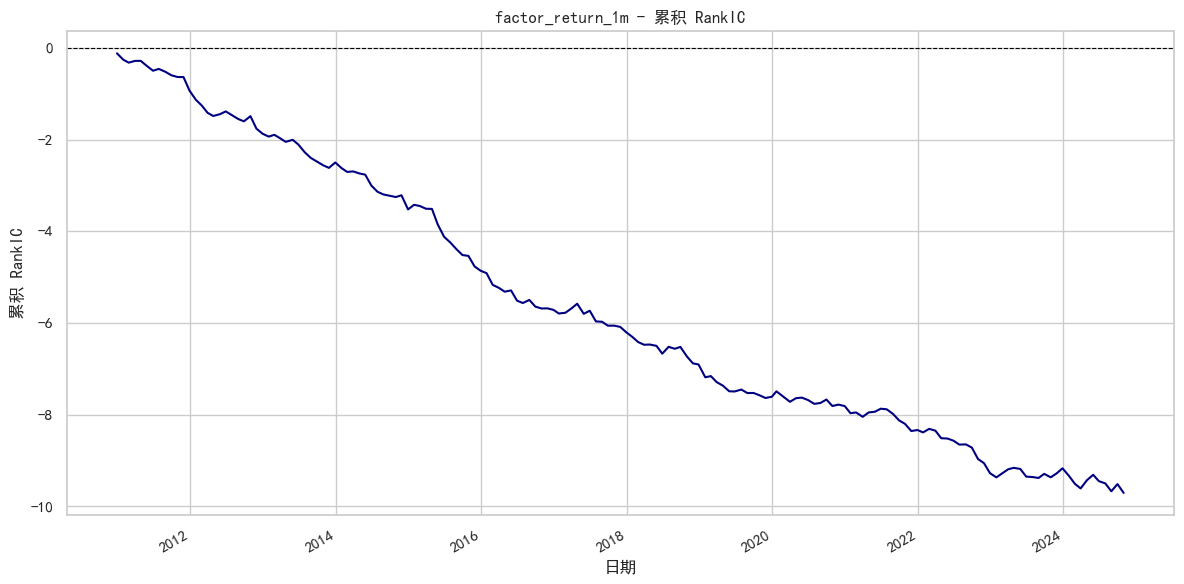

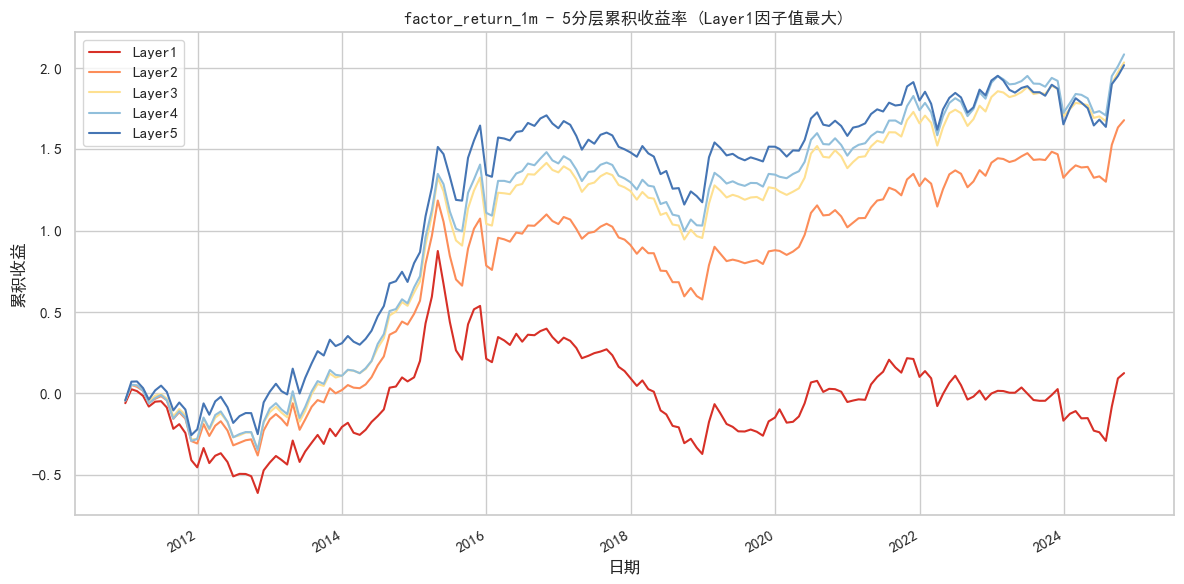

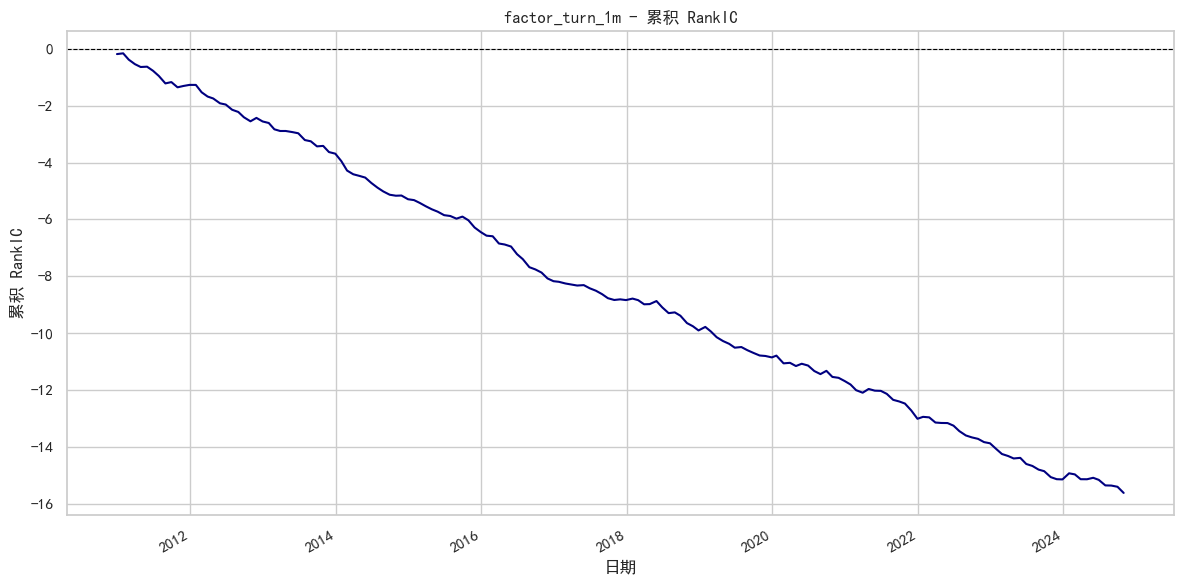

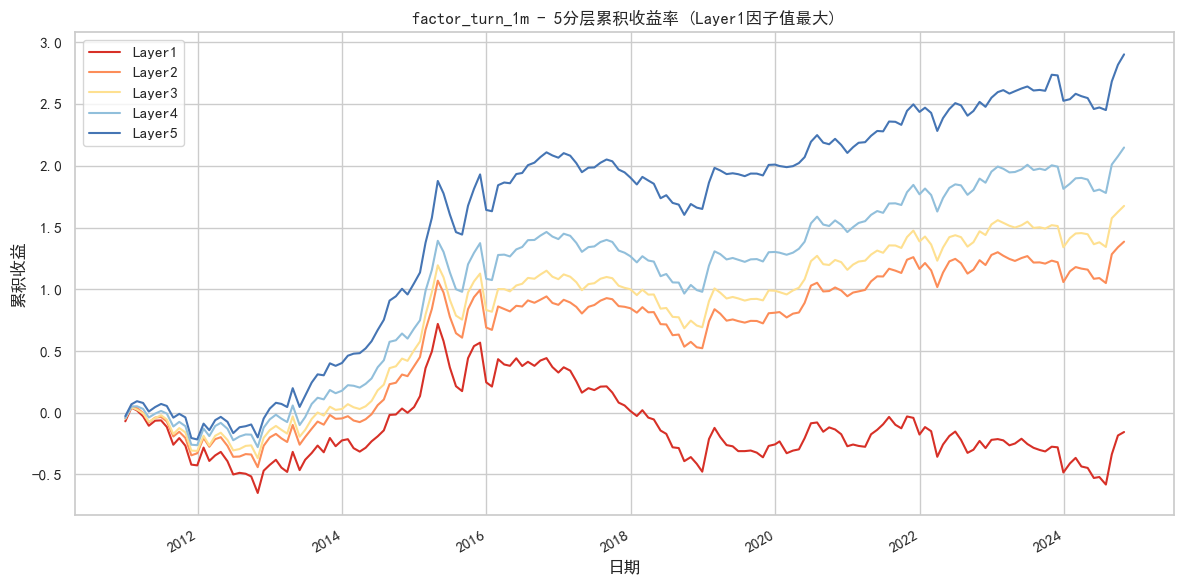

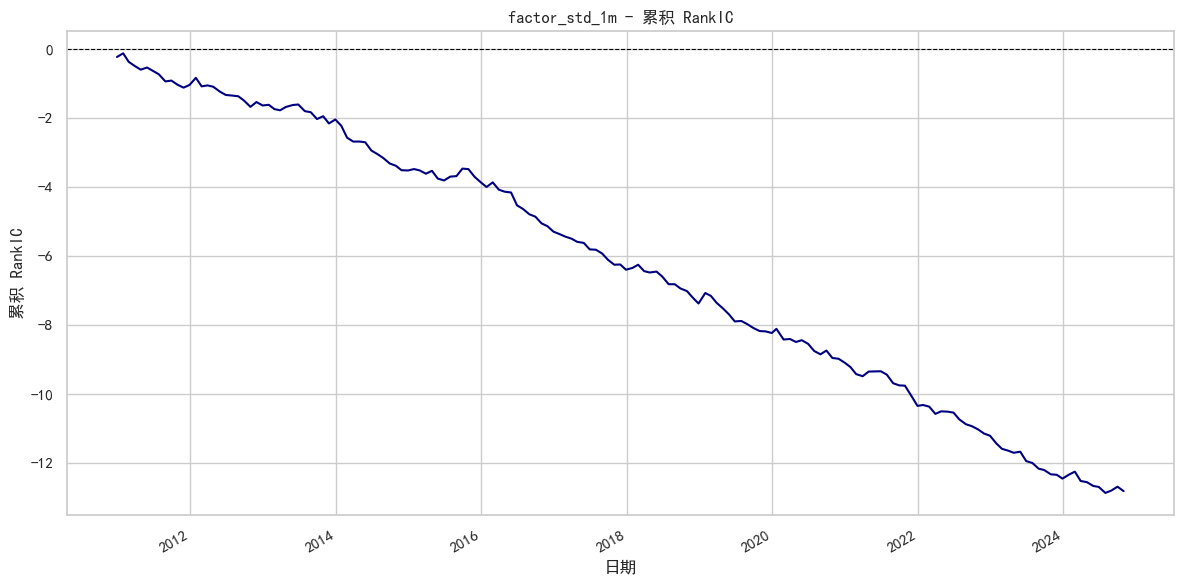

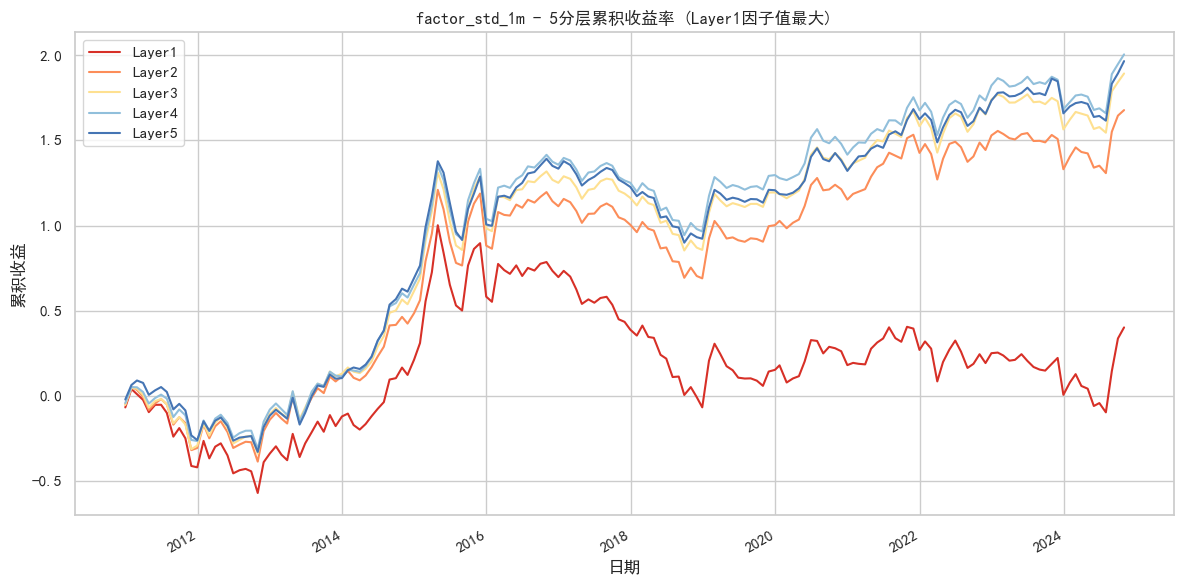

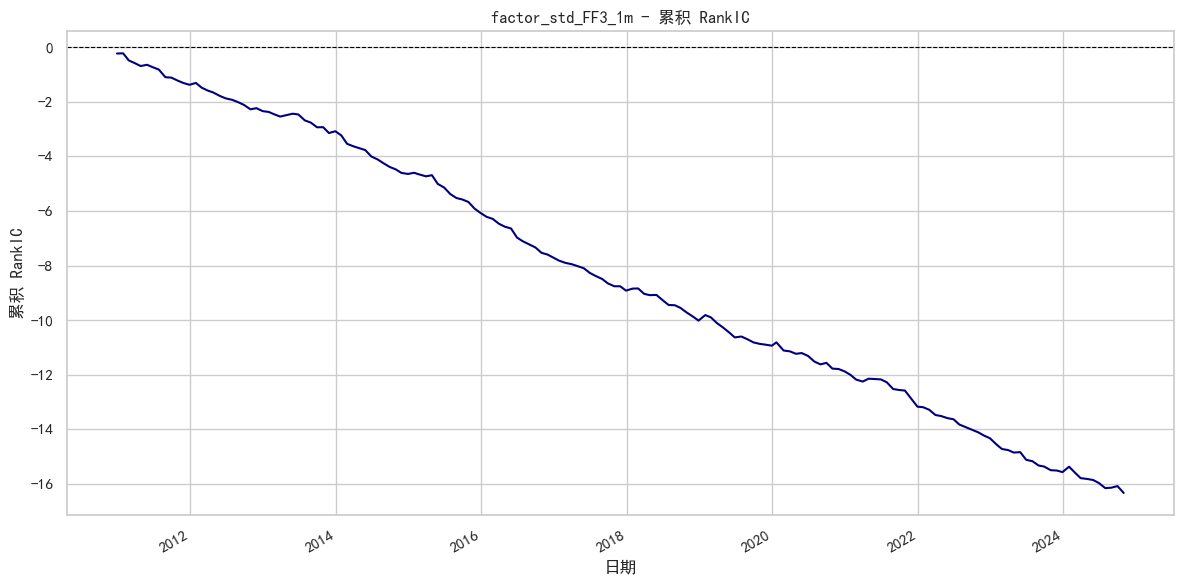

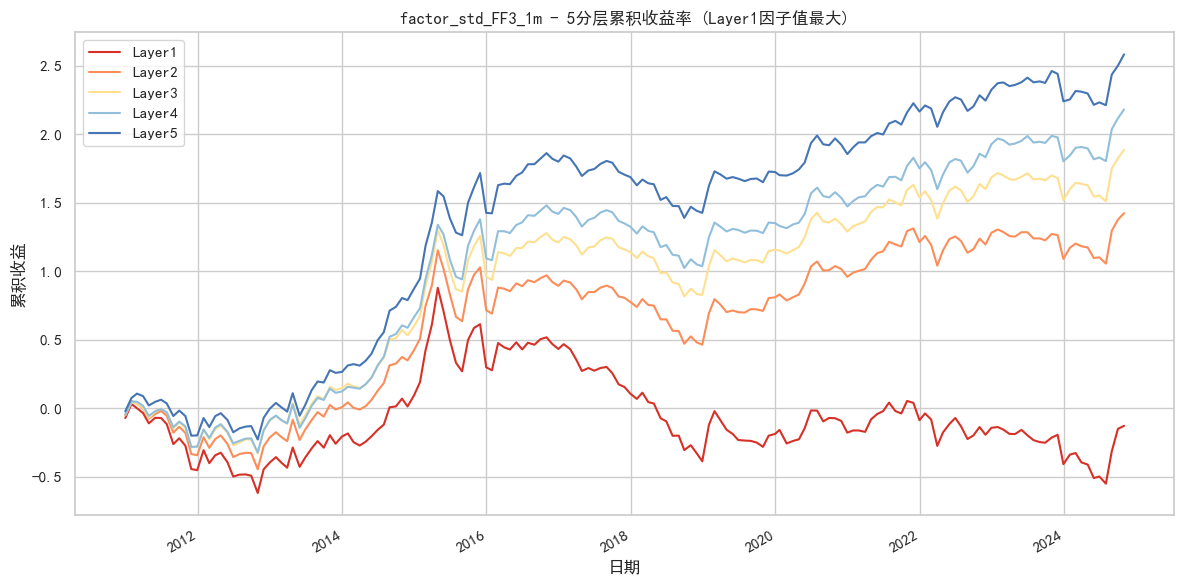

In [55]:
results = factor_tests(loader,output)
for k, v in results.items():
    v.to_csv(f"{k}.csv")
plot(results)